
# Comparing Image Shapley-Value Explainers
### Shapiq Vision &nbsp;·&nbsp; ProxySHAP &nbsp;·&nbsp; Captum KernelSHAP



In this notebook, we compare three different Shapley-value attribution methods on the same image classification task, to see how much their explanations agree - and how much compute each one needs to get there.

**The setup:** a pretrained ResNet-18 classifies a photo containing a golden retriever playing on a guitar. We pick two of its predictions to explain - the **top-1 class**: acoustic guitar and the **5th-ranked class**: golden retriever - and for each one, ask three different Shapley-value methods: 
*which regions of the image pushed the prediction toward this class?*

**The "players":** rather than explaining pixel-by-pixel (which is both expensive and noisy), we first segment the image into ~50 superpixels using SLIC. Each superpixel is treated as one "player" in a coalition game - a region that can be either present (its original pixels) or absent (replaced with the image's average color).

**The three methods, all given the same budget** (1024 model calls)

**What we compare:**
1. Runtime and model-call efficiency of each method
2. Per-superpixel attribution heatmaps, side by side
3. The top-10 most influential superpixels each method picks out

All three methods are run twice - once explaining the top-1 predicted class, once explaining the 5th-ranked class - so we can also see whether methods that agree on an "easy" top prediction still agree on a fainter, lower-ranked one.

In [43]:
# shapiq.vision is not on PyPI yet - install shapiq from the project fork
!pip install "git+https://github.com/S2k-1/shapiq.git@feature/protocols" captum --quiet

## 1 · Setup

In [44]:
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import TwoSlopeNorm
from PIL import Image
from torchvision import models, transforms
from skimage.segmentation import slic, mark_boundaries

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu



## 2 · Config

- `IMAGE_PATH` - the image to explain.
- `N_SEGMENTS` - target number of superpixels (players in the game).
- `BUDGET` - number of value-function evaluations each method is allowed. 


In [45]:
IMAGE_PATH = "images/guitardog.png"
N_SEGMENTS = 50
BUDGET = 1024          # model calls allowed per method

MAX_ORDER = 1          # Shapley order (1 = per-player importance, no interactions)
INDEX = "SV"           # Shapley value index
ADJUSTMENT = "msr"     # ProxySHAP residual-adjustment method


## 3 · Load the image and the model

We use a pretrained ResNet-18. The dog-with-a-guitar photo is a nice stress test: it contains a golden retriever's face, a guitar, a hat, and clothing, so it's interesting to see which regions the explainers credit for the top prediction.


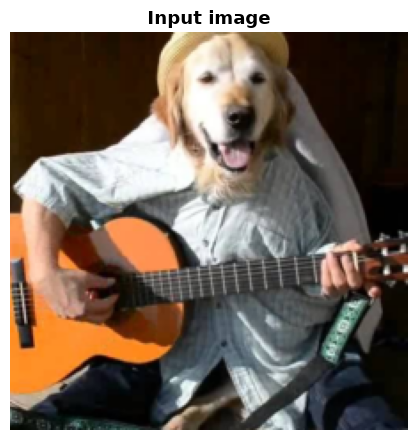

Top-5 predictions:
  acoustic guitar                40.2%
  stage                          21.6%
  electric guitar                15.7%
  harmonica                      4.5%
  golden retriever               2.4%

Explaining class: 'acoustic guitar' and 'golden retriever'


In [46]:
pil_image = Image.open(IMAGE_PATH).convert("RGB")

resize_crop = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
])
to_tensor_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

resized_image = resize_crop(pil_image)
image_np = np.array(resized_image)                       # (224, 224, 3), for plotting/masking
tensor_image = to_tensor_norm(resized_image).unsqueeze(0).to(device)  # (1, 3, 224, 224)

weights = models.ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights).eval().to(device)
categories = weights.meta["categories"]

with torch.no_grad():
    probs_full = torch.softmax(model(tensor_image), dim=1)[0]
top5 = torch.topk(probs_full, 5)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.imshow(image_np)
ax.axis("off")
ax.set_title("Input image", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Top-5 predictions:")
for p, i in zip(top5.values, top5.indices):
    print(f"  {categories[i]:<30s} {p.item()  * 100:.1f}%")

target_class_guitar = int(top5.indices[0].item())
target_class_golden = int(top5.indices[4].item())
print(f"\nExplaining class: '{categories[target_class_guitar]}' and '{categories[target_class_golden]}'")


## 4 · Define the players: superpixel regions

Each superpixel is one "player" in the coalition game.


Requested 50 superpixels, got 39 players


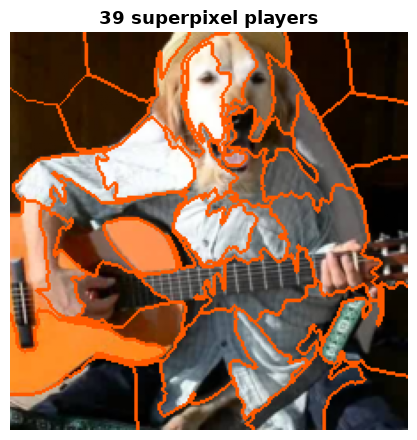

In [47]:
segments = slic(image_np, n_segments=N_SEGMENTS, compactness=12, sigma=1, start_label=0)
n_players = int(segments.max()) + 1
print(f"Requested {N_SEGMENTS} superpixels, got {n_players} players")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.imshow(mark_boundaries(image_np, segments, color=(1, 0.35, 0)))
ax.set_title(f"{n_players} superpixel players", fontsize=13, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

## 5 · Average baseline

We use the **per-channel average pixel value of the image** as the baseline, rather than alternatives like a black image, blurred image, or random noise. This was chosen experimentally: across a set of comparison runs done in the other notebook in this repo, the mean-color baseline gave the most stable and interpretable attributions, compared to the alternatives tested.

In [48]:
spatial_dims = tuple(range(tensor_image.ndim - 2, tensor_image.ndim))  # Gets last two dims (H, W)
mean_vals = tensor_image.mean(dim=spatial_dims, keepdim=True)
baseline = mean_vals.expand_as(tensor_image)

seg_t = torch.from_numpy(segments).to(device)  # (H, W) long tensor, same superpixel ids as `segments`


## 6 · Method A - Shapiq Vision


In [49]:
from shapiq.vision import CNNArchitecture, ImageExplainer, MeanColorMasking
from shapiq.vision.players import CustomPlayerStrategy

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


class CountedModel(torch.nn.Module):
    """shapiq feeds [0, 1] images, so normalization lives inside the model.
    Counting forward-pass rows keeps budget usage comparable across methods."""

    def __init__(self, model):
        super().__init__()
        self.model = model
        self.n_calls = 0

    def forward(self, x):
        self.n_calls += x.shape[0]
        return self.model(normalize(x))


counted_model = CountedModel(model).eval().to(device)

t0 = time.time()

architecture = CNNArchitecture(
    model=counted_model,
    masking_strategy=MeanColorMasking(),
    player_strategy=CustomPlayerStrategy(segments),
)
explainer = ImageExplainer(
    model=architecture,
    data=image_np,
    class_index=target_class_guitar,
    index=INDEX,
    max_order=MAX_ORDER,
    random_state=SEED,
)
iv_vision = explainer.explain(budget=BUDGET)

time_vision = time.time() - t0
calls_vision = counted_model.n_calls
vals_vision = iv_vision.get_n_order_values(1)
print(f"Method A - done in {time_vision:.1f}s, {calls_vision} model calls")

Method A - done in 16.6s, 1025 model calls



## 7 · Method B - ProxySHAP

ProxySHAP takes a two-stage approach: it fits a cheap **proxy model** to approximate the value function, extracts that proxy's
Shapley values exactly, and then separately estimates *only the leftover error* the proxy didn't capture.

This works because Shapley values are linear in the value function. For any proxy $\hat{v}$ built from a sample of coalitions:

$$
\phi_i(v) = \underbrace{\phi_i(\hat{v})}_{\text{exact proxy term}} + \underbrace{\phi_i(v - \hat{v})}_{\text{residual term}}
$$

**The proxy term.** A tree-based surrogate is trained to predict $v(z)$ from the sampled coalitions $z$. Because a tree is a sum of piecewise-constant indicator functions over its leaves, $\phi_i(\hat{v})$ has a closed-form solution computable in a single pass over the tree - no sampling error here at all, since it's an *exact* Shapley value of the proxy itself.

**The residual term.** The proxy is never a perfect fit, so $v - \hat{v}$ (the part of the value function the tree missed) still needs to be estimated. This is done via **Maximum Sample Reuse (MSR)**, which reuses the same sampled coalitions to build an unbiased Monte Carlo estimate of the residual's Shapley values:

$$
\hat{\phi}_i^{\text{MSR}}(v - \hat{v}) = \frac{1}{|\mathcal{T}|} \sum_{z \in \mathcal{T}} (v(z) - \hat{v}(z)) \cdot w_i(z)
$$

where $w_i(z)$ is a signed weight depending on whether player $i$ is present in coalition $z$ and how large $z$ is. Because $\hat v$ has already absorbed most of $v$'s structure, the residual $v - \hat v$ is typically small and much less noisy than $v$ itself - which is why correcting the *residual* rather than estimating $v$'s Shapley values directly tends to need far fewer samples for the same accuracy.

In [50]:
def value_function(coalitions: np.ndarray) -> np.ndarray:
    """coalitions: (n_players,) or (n_coalitions, n_players) bool array.
    Returns P(target_class) for each coalition. Increments the global call
    counter so each method's budget usage can be reported later."""
    global n_calls
    n_calls += coalitions.shape[0]
    outputs = []
    for coalition in coalitions:
        active_ids = np.where(coalition)[0]
        if len(active_ids) == 0:
            mask = torch.zeros_like(seg_t, dtype=torch.bool)
        else:
            active_t = torch.as_tensor(active_ids, device=device)
            mask = torch.isin(seg_t, active_t)
        masked = torch.where(mask, tensor_image[0], baseline[0]).unsqueeze(0)
        with torch.no_grad():
            out = model(masked)[:, current_target]
        outputs.append(out.item())
    return np.array(outputs)

In [51]:
from shapiq.approximator import ProxySHAP

current_target = target_class_guitar
n_calls = 0
t0 = time.time()

approximator = ProxySHAP(
    n=n_players,
    max_order=MAX_ORDER,
    index=INDEX,
    adjustment=ADJUSTMENT,
    random_state=SEED,
)
iv_proxy = approximator.approximate(budget=BUDGET, game=value_function)

time_proxy = time.time() - t0
calls_proxy = n_calls
vals_proxy = np.array([iv_proxy[(i,)] for i in range(n_players)])
print(f"Method B - done in {time_proxy:.1f}s, {calls_proxy} model calls")

Method B - done in 25.0s, 1024 model calls



## 8 · Method C - Captum KernelShap


Given the exact Shapley value definition from the section above, [KernelSHAP](https://arxiv.org/pdf/1705.07874)
(Lundberg & Lee, 2017) shows that $\phi_i$ can also be recovered as the
solution to a **weighted least-squares regression**, rather than by summing
over all $2^n$ coalitions directly.

Concretely, define a linear model over coalition vectors $z \in \{0,1\}^n$:

$$
g(z) = \phi_0 + \sum_{i=1}^{n} \phi_i z_i
$$

where $z_i = 1$ means superpixel $i$ is present. Kernel SHAP finds the
$\phi_i$ that minimize:

$$
\mathcal{L}(\phi) = \sum_{z \subseteq N} \pi_x(z) \, \Big( v(z) - g(z) \Big)^2
$$

with the **Shapley kernel** as the weighting function:

$$
\pi_x(z) = \frac{n-1}{\binom{n}{|z|}\,|z|\,(n-|z|)}
$$

This kernel is what makes the regression's solution equal to the Shapley values: it heavily up-weights very small and very large coalitions, where a player's marginal contribution is least confounded by interactions with others, and down-weights mid-sized coalitions. 

**The approximation.** Evaluating all $2^n$ coalitions is what we're trying to avoid, so in practice Kernel SHAP:

1. Samples a budget of $m$ coalitions $z^{(1)}, \dots, z^{(m)}$ (weighted by $\pi_x$, so extreme coalition sizes are sampled more often),
2. Evaluates $v(z^{(k)})$ for each - one model forward pass per sample,
3. Solves the weighted least-squares problem above restricted to just those $m$ samples.

As $m \to 2^n$, this converges to the exact Shapley values; with a finite budget, it's an unbiased estimator whose variance shrinks as $m$ grows. That sample budget is exactly `n_samples=BUDGET` in the code below

In [52]:
from captum.attr import KernelShap

n_calls = 0
t0 = time.time()

feature_mask = seg_t.long().unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1)

def _counted_model(x):
    global n_calls
    n_calls += x.shape[0]
    return model(x)

ks = KernelShap(_counted_model)

attributions = ks.attribute(
    inputs=tensor_image,
    baselines=baseline,
    target=target_class_guitar,
    feature_mask=feature_mask,
    n_samples=BUDGET,
)

time_captum = time.time() - t0
calls_captum = n_calls
attr_np = attributions[0, 0].detach().cpu().numpy()
vals_captum = np.array([attr_np[segments == i].mean() for i in range(n_players)])
print(f"Method C - done in {time_captum:.1f}s, {calls_captum} model calls")

Method C - done in 28.0s, 1024 model calls


## Explanations for a different class
Additionally we will explain a different class of the model

In [53]:
# 1. Shapiq Vision
explainer_golden = ImageExplainer(
    model=architecture,
    data=image_np,
    class_index=target_class_golden,
    index=INDEX,
    max_order=MAX_ORDER,
    random_state=SEED,
)
iv_vision_golden = explainer_golden.explain(budget=BUDGET)
vals_vision_golden = iv_vision_golden.get_n_order_values(1)

# 2. ProxySHAP
current_target = target_class_golden
approximator_golden = ProxySHAP(
    n=n_players,
    max_order=MAX_ORDER,
    index=INDEX,
    adjustment=ADJUSTMENT,
    random_state=SEED,
)
iv_proxy_golden = approximator_golden.approximate(budget=BUDGET, game=value_function)
vals_proxy_golden = np.array([iv_proxy_golden[(i,)] for i in range(n_players)])

# 3. Captum KernelSHAP
attributions_golden = ks.attribute(
    inputs=tensor_image,
    baselines=baseline,
    target=target_class_golden,
    feature_mask=feature_mask,
    n_samples=BUDGET,
)
attr_np_golden = attributions_golden[0, 0].detach().cpu().numpy()
vals_captum_golden = np.array([attr_np_golden[segments == i].mean() for i in range(n_players)])

In [54]:
results_golden = {}
results_golden["A - Shapiq Vision"] = vals_vision_golden
results_golden["B - ProxySHAP"] = vals_proxy_golden
results_golden["C - Captum KernelSHAP"] = vals_captum_golden

## 9 · Runtime & budget summary

In [55]:
import pandas as pd

results = {}
results["A - Shapiq Vision"] = (vals_vision, time_vision, calls_vision)
results["B - ProxySHAP"] = (vals_proxy, time_proxy, calls_proxy)
results["C - Captum KernelSHAP"] = (vals_captum, time_captum, calls_captum)

summary = pd.DataFrame({
    "Method": list(results.keys()),
    "Wall time (s)": [v[1] for v in results.values()],
    "Model calls": [v[2] for v in results.values()],
})
summary["Time / call (ms)"] = 1000 * summary["Wall time (s)"] / summary["Model calls"]
summary.round({"Wall time (s)": 2, "Time / call (ms)": 3}).set_index("Method")


,Wall time (s),Model calls,Time / call (ms)
Method,,,
A - Shapiq Vision,16.63,1025,16.221
B - ProxySHAP,25.05,1024,24.460
C - Captum KernelSHAP,27.99,1024,27.334



## 10 · Visual comparison

Each heatmap shows per-superpixel Shapley values overlaid on the original image


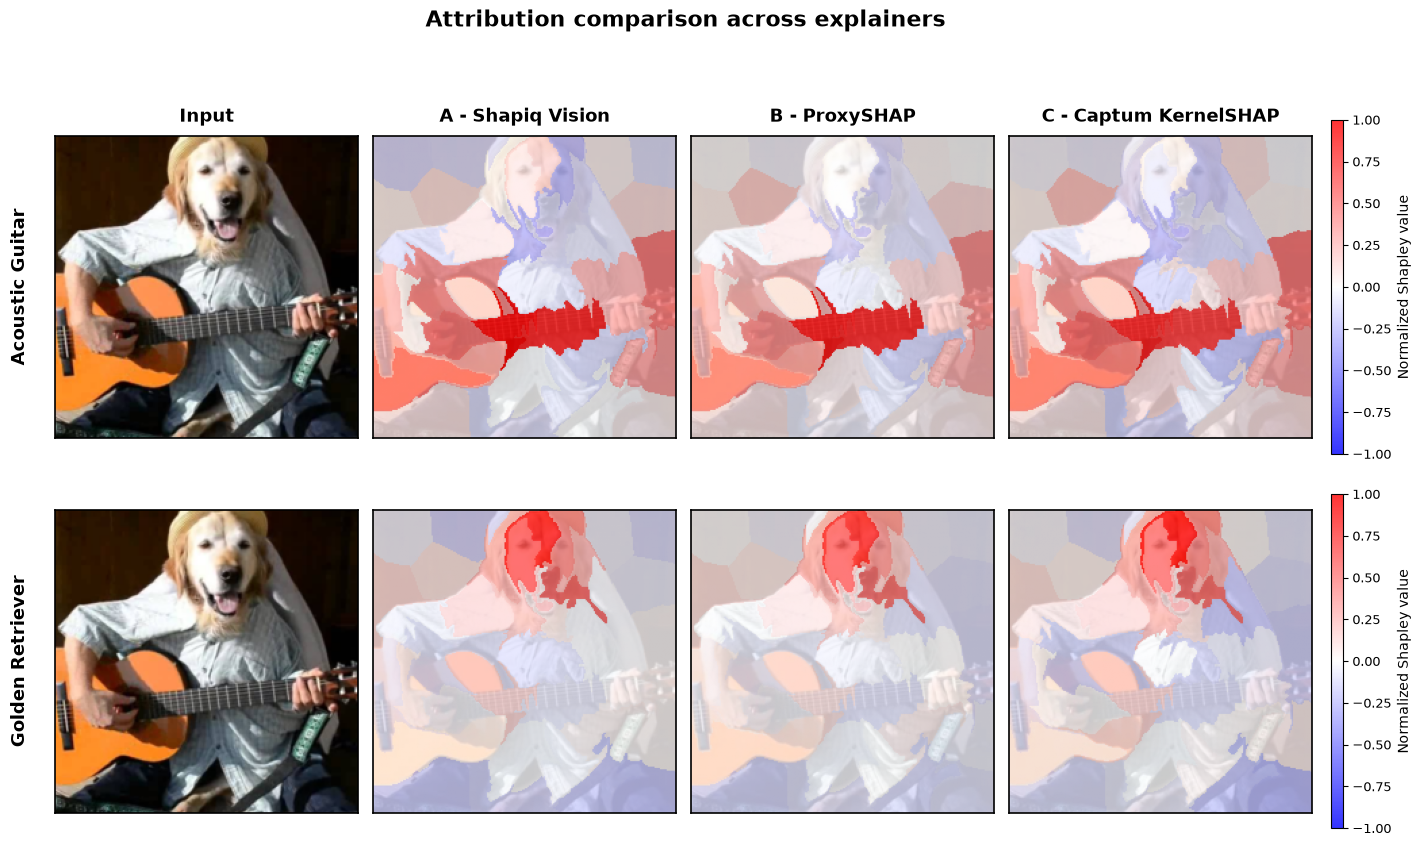

In [ ]:
def attribution_map(values, segments):
    out = np.zeros(segments.shape, dtype=np.float32)
    for i, v in enumerate(values):
        out[segments == i] = v
    return out

names = list(results.keys())
rows = [
    (target_class_guitar, {name: results[name][0] for name in names}),
    (target_class_golden, results_golden),
]

n_cols = len(names) + 1
fig, axes = plt.subplots(
    2, n_cols,
    figsize=(4.2 * n_cols, 4.6 * 2),
    gridspec_kw={"wspace": 0.05, "hspace": 0.12},
)

for row_idx, (target_class, vals_dict) in enumerate(rows):
    maps = [attribution_map(vals_dict[name], segments) for name in names]
    vmax = max(np.abs(m).max() for m in maps)
    maps = [m / vmax for m in maps]
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    ax0 = axes[row_idx, 0]
    ax0.imshow(image_np)
    ax0.set_xticks([]); ax0.set_yticks([])
    for spine in ax0.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
    if row_idx == 0:
        ax0.set_title("Input", fontsize=13, fontweight="bold", pad=10)
    ax0.text(
        -0.12, 0.5, categories[target_class].replace("_", " ").title(),
        transform=ax0.transAxes, fontsize=13, fontweight="bold",
        rotation=90, va="center", ha="center",
    )

    for ax, m, title in zip(axes[row_idx, 1:], maps, names):
        ax.imshow(image_np)
        im = ax.imshow(m, cmap="RdBu_r", norm=norm, alpha=0.8)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.2)
        if row_idx == 0:
            ax.set_title(title, fontsize=13, fontweight="bold", pad=10)

    cbar = fig.colorbar(im, ax=axes[row_idx, :], fraction=0.02, pad=0.015, aspect=30)
    cbar.set_label("Normalized Shapley value", fontsize=10)
    cbar.ax.tick_params(labelsize=9)

fig.suptitle(
    "Attribution comparison across explainers",
    fontsize=16, fontweight="bold", y=1.0,
)
plt.show()

The results seem reasonable, as all three methods focus on the relevant part of the image. Each method assigns importance to most of the guitar, with the highest attribution concentrated on the central part of the instrument. While there are some differences between the explanations, they are relatively small.

For the golden retriever, the results are highly consistent across all three methods. All of them primarily focus on the dog's face while assigning little or no importance to almost all of the remaining superpixels.


## 11 · Top contributing superpixels per method

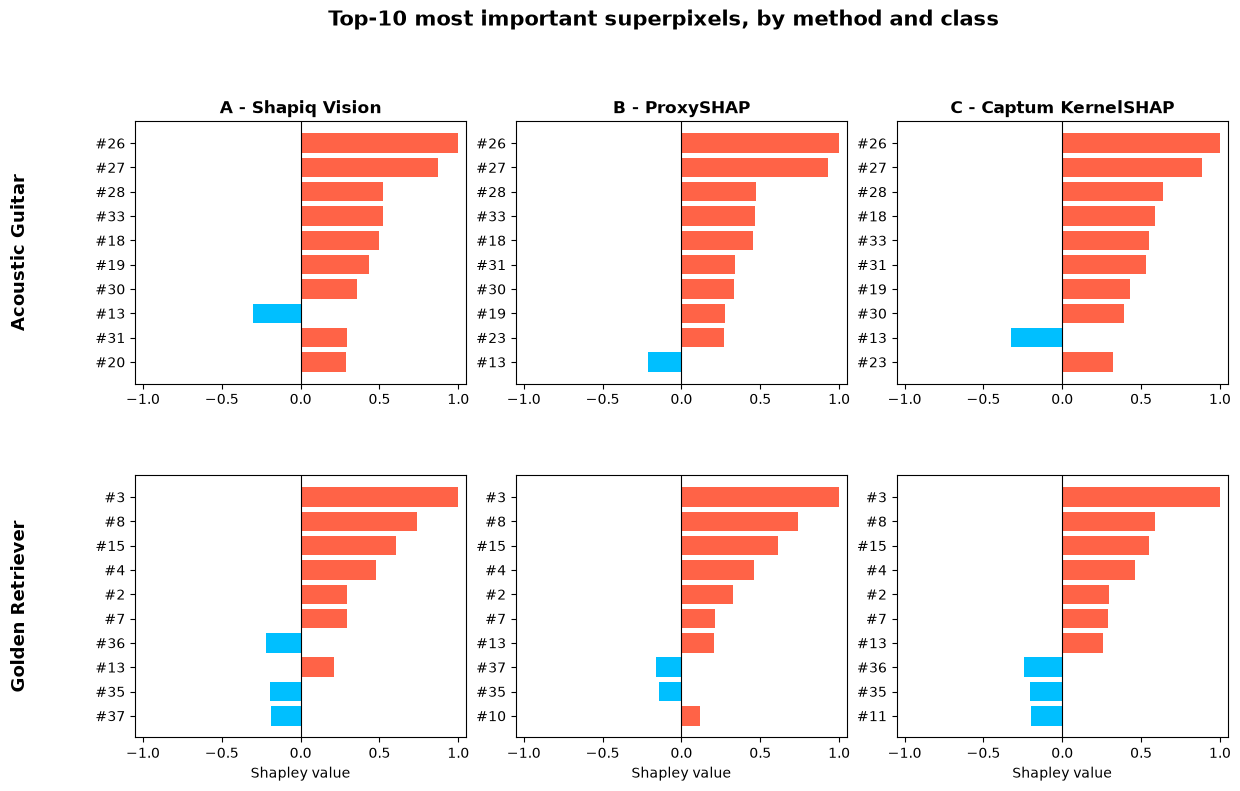

In [57]:
rows = [
    (target_class_guitar, {name: results[name][0] for name in names}),
    (target_class_golden, results_golden),
]

n_cols = len(names)
fig, axes = plt.subplots(
    2, n_cols,
    figsize=(4.7 * n_cols, 4 * 2),
    gridspec_kw={"wspace": 0.15, "hspace": 0.35},
)

for row_idx, (target_class, vec) in enumerate(rows):
    for ax, name in zip(axes[row_idx], names):
        v_raw = vec[name]
        vmax = np.abs(v_raw).max()          # own scale per panel, not shared
        v = v_raw / vmax

        order = np.argsort(np.abs(v))[::-1][:10]
        colors = ["tomato" if v[i] >= 0 else "deepskyblue" for i in order]
        ax.barh([f"#{i}" for i in order][::-1], v[order][::-1], color=colors[::-1])

        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_xlim(-1.05, 1.05)
        if row_idx == 1:
            ax.set_xlabel("Shapley value")
        if row_idx == 0:
            ax.set_title(name, fontsize=12, fontweight="bold")

    axes[row_idx, 0].text(
        -0.35, 0.5, categories[target_class].replace("_", " ").title(),
        transform=axes[row_idx, 0].transAxes, fontsize=13, fontweight="bold",
        rotation=90, va="center", ha="center",
    )

fig.suptitle("Top-10 most important superpixels, by method and class", fontsize=15, fontweight="bold", y=1.02)
plt.show()

The ranking of the five most important superpixels is nearly identical across all three methods. 

Overall, the explanations produced by the methods are highly comparable, and all perform well on this image under the chosen settings. Among them, Shapiq Vision is the fastest, making it the most practical choice in this case.
